In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

x = np.random.randn(50)
y = 2 * x**2 + 3 * x + 5 + np.random.randn(50)
coeffs = np.polyfit(x, y, 2)

p = np.poly1d(coeffs)
p

poly1d([2.04651522, 3.18296525, 4.95125074])

In [4]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(2)
x_poly = poly.fit_transform(x.reshape(-1, 1))
x_poly.shape

(50, 3)

In [5]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x_poly,y)

LinearRegression()

In [6]:
x.reshape(-1, 1).shape

(50, 1)

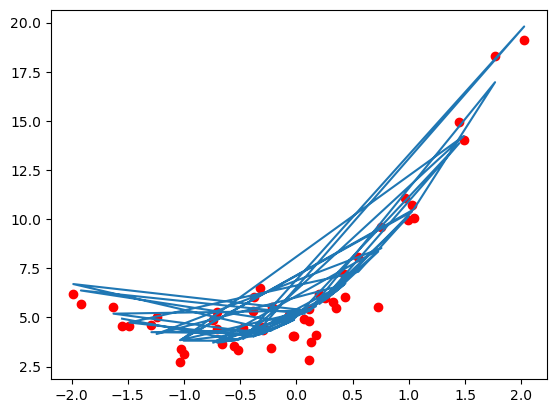

In [7]:
plt.scatter(x,y, color="r")
plt.plot(x, lin_reg.predict(x_poly))
plt.show()

In [8]:
from sklearn.metrics import r2_score
r2_score(y, lin_reg.predict(x_poly))

0.9217049635225991

In [9]:
y_pred = lin_reg.predict(x_poly)

In [10]:
mse = sum((y-y_pred)**2) / 50

In [11]:
mse

1.0368573997145956

In [12]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y, y_pred)

1.0368573997145956

In [13]:
lin_reg.score(x_poly, y)

0.9217049635225991

In [14]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=50, max_iter=100, tol=0.1)
ridge_reg.fit(x_poly, y)
ridge_reg.score(x_poly, y)

0.6543916108461907

In [16]:
lin_reg.coef_

array([0.        , 3.18296525, 2.04651522])

In [22]:
lambd = 1.0
ridge = sum((y-y_pred)**2) / 50 + lambd*sum(lin_reg.coef_**2)
ridge

15.356349758675389

In [26]:
from sklearn.linear_model import ElasticNet
model = ElasticNet(alpha=0.1, l1_ratio=0.5)  
# alpha = ceza şiddeti
# l1_ratio = 1 → saf Lasso, 0 → saf Ridge, ara değer → karışım

model.fit(x.reshape(-1, 1), y)
model.score(x.reshape(-1, 1), y)

0.5358469654863525